# Customer Churn Prediction

## Project Overview

This project develops a machine learning model to predict customer churn for **Interconnect**, a telecommunications company.

The objective is to identify customers who are most likely to cancel their services, allowing the company to implement targeted retention strategies and reduce customer attrition.

Several classification models were evaluated, including **Logistic Regression**, **Random Forest**, and **Gradient Boosting**. After hyperparameter tuning, the optimized **Gradient Boosting** model achieved the best overall predictive performance and was selected as the final model.

The project covers the complete machine learning workflow, including data cleaning, exploratory data analysis, feature engineering, model comparison, hyperparameter tuning, and feature importance analysis.

## Business Problem

Interconnect is a telecommunications company seeking to reduce customer churn. Customer attrition leads to revenue loss and increases the cost of acquiring new customers, making customer retention a key business objective.

The goal of this project is to develop a machine learning model capable of identifying customers who are most likely to cancel their services. These predictions can help the marketing team target retention campaigns by offering personalized promotions or special plans to customers at higher risk of churn.

By identifying potential churners in advance, the company can improve customer retention, optimize marketing investments, and support data-driven decision-making.

---

## Target Variable and Predictors

The target variable for this project is **churn**, which was created from the `EndDate` column. Customers with an `EndDate` equal to `"No"` were considered active, while customers with a cancellation date were labeled as churned.

The main features expected to contribute to churn prediction include:

- Contract type (`Type`)
- Monthly and total charges (`MonthlyCharges` and `TotalCharges`)
- Payment method (`PaymentMethod`)
- Paperless billing (`PaperlessBilling`)
- Internet service type (`InternetService`)
- Additional services such as `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, and `StreamingMovies`
- Customer demographic information, including `Partner`, `Dependents`, and `SeniorCitizen`

These features will be evaluated during model development to determine their predictive importance.

---

## Modeling Approach

Since the objective is to predict whether a customer will churn or remain active, this project is formulated as a **binary classification problem**.

The following machine learning algorithms were evaluated:

- **Logistic Regression:** used as a baseline model because it is simple, fast, and easy to interpret.
- **Random Forest:** selected for its ability to capture complex relationships between variables and its strong performance on tabular data.
- **Gradient Boosting:** evaluated for its capability to build highly accurate predictive models by combining multiple decision trees.

All models were trained and evaluated using the same datasets and evaluation metrics to ensure a fair comparison.

---

## Evaluation Metrics (KPIs)

The models were evaluated using multiple classification metrics.

- **ROC-AUC:** Primary evaluation metric used to compare model performance, as it measures the model's ability to distinguish between churned and non-churned customers across different classification thresholds.

- **F1-score:** Used as a complementary metric because it balances precision and recall, making it particularly useful for imbalanced classification problems.

- **Accuracy:** Measures the proportion of correctly classified observations. Since approximately 73.5% of customers remained active, the baseline accuracy is already relatively high, making this metric insufficient on its own.

- **Precision:** Measures the proportion of predicted churned customers who actually canceled their services. Higher precision helps reduce unnecessary retention offers.

- **Recall:** Measures the proportion of actual churned customers correctly identified by the model. A higher recall is desirable because failing to identify a customer at risk of churn may result in revenue loss.

---

## Methodology

The project followed a structured machine learning workflow to ensure reliable and reproducible results.

First, the datasets were merged using the `customerID` field. Data quality was assessed by checking for duplicate records, missing values, inconsistent data types, and invalid entries. The `TotalCharges` column was converted to a numeric format, and the target variable was created based on the `EndDate` column.

The dataset was then divided into training and testing sets using a stratified split to preserve the original proportion of churned and non-churned customers. All preprocessing steps were fitted only on the training data and later applied to the test data to prevent data leakage.

Different preprocessing pipelines were used according to the requirements of each algorithm. Logistic Regression required categorical encoding and feature scaling, while Random Forest and Gradient Boosting were trained without feature scaling, since tree-based models are not sensitive to differences in feature magnitude.

Hyperparameter tuning was performed using **5-fold Stratified Cross-Validation** to identify the best configuration for each model while maintaining the class distribution in every fold.

The final model was selected primarily based on **ROC-AUC**, with **F1-score**, **Accuracy**, **Precision**, and **Recall** used as complementary evaluation metrics.

---

## Stakeholders

The main stakeholders of this project include:

- **Marketing Team:** can target retention campaigns and promotional offers to customers at higher risk of churn.
- **Sales Team:** can recommend more suitable plans to help reduce customer attrition.
- **Business Managers:** can use the model's predictions to support strategic, data-driven decision-making.
- **Data Science and IT Teams:** are responsible for deploying, monitoring, and maintaining the predictive model.

## Initial Data Exploration

In [59]:
import pandas as pd

contract = pd.read_csv('data/final_provider/contract.csv')
personal = pd.read_csv('data/final_provider/personal.csv')
internet = pd.read_csv('data/final_provider/internet.csv')
phone = pd.read_csv('data/final_provider/phone.csv')

display(contract.head())
display(personal.head())
display(internet.head())
display(phone.head())

contract.info()
print()
personal.info()
print()
internet.info()
print()
phone.info()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   

In [2]:
print('Contract:', contract.shape)
print('Personal:', personal.shape)
print('Internet:', internet.shape)
print('Phone:', phone.shape)

Contract: (7043, 8)
Personal: (7043, 5)
Internet: (5517, 8)
Phone: (6361, 2)


The `contract` and `personal` datasets contain records for all **7,043** customers in the database. In contrast, the `internet` and `phone` datasets contain fewer records, indicating that not every customer subscribed to these services. This difference is expected and will be taken into account during the data integration process.

In [60]:
print('Duplicates - Contract')
print(contract.duplicated().sum())
print()

print('Duplicates - Personal')
print(personal.duplicated().sum())
print()

print('Duplicates - Internet')
print(internet.duplicated().sum())
print()

print('Duplicates - Phone')
print(phone.duplicated().sum())

Duplicates - Contract
0

Duplicates - Personal
0

Duplicates - Internet
0

Duplicates - Phone
0


In [61]:
print('Missing Values - Contract')
print(contract.isna().sum())
print()

print('Missing Values - Personal')
print(personal.isna().sum())
print()

print('Missing Values - Internet')
print(internet.isna().sum())
print()

print('Missing Values - Phone')
print(phone.isna().sum())

Missing Values - Contract
customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

Missing Values - Personal
customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64

Missing Values - Internet
customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64

Missing Values - Phone
customerID       0
MultipleLines    0
dtype: int64


## Initial Data Quality Assessment

The initial inspection showed no duplicate records across any of the four datasets. No missing values (`NaN`) were identified in the analyzed columns.

However, the `TotalCharges` column was imported as an `object` data type, even though it represents a numerical variable. This suggests the presence of empty strings or inconsistent values that will require further investigation during the data preparation stage.

Additionally, the `internet` and `phone` datasets contain fewer records than the `contract` and `personal` datasets. This indicates that some customers did not subscribe to these services rather than suggesting the presence of missing values.

In [5]:
contract['TotalCharges'].value_counts().head(20)

TotalCharges
         11
20.2     11
19.75     9
20.05     8
19.9      8
19.65     8
45.3      7
19.55     7
20.15     6
20.25     6
19.45     6
20.3      5
20.45     5
19.85     4
69.9      4
20.4      4
70.6      4
19.2      4
69.65     4
44        4
Name: count, dtype: int64

In [6]:
(contract['TotalCharges'] == ' ').sum()

np.int64(11)

In [7]:
(contract['TotalCharges'] == '').sum()

np.int64(0)

## TotalCharges Column Assessment

It was identified that **11 records** in the `TotalCharges` column contained only blank spaces, causing the column to be imported as a text (`object`) data type.

Further investigation showed that all of these records belong to customers who started their contracts on **2020-02-01** and were still active at the time the data was collected. Since these customers had only recently joined the company, they had not yet accumulated any total charges, which explains the missing values.

During the data preparation stage, these blank values were converted to numeric values and handled appropriately, allowing the `TotalCharges` column to be used in the machine learning models.

In [8]:
contract.describe()

,MonthlyCharges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


## Descriptive Statistics

The `MonthlyCharges` variable ranges from **18.25** to **118.75**, with a mean of approximately **64.76** and a median of **70.35**.

The difference between the mean and the median suggests that the distribution may not be perfectly symmetric. In addition, the wide range of monthly charges indicates that customers subscribe to plans and services with considerably different costs.

Since the monthly charge is directly related to the customer's subscribed plan and services, this feature may provide valuable information for predicting customer churn.

In [9]:
contract.describe(include='object')

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,TotalCharges
count,7043,7043,7043,7043,7043,7043,7043
unique,7043,77,5,3,2,4,6531
top,7590-VHVEG,2014-02-01,No,Month-to-month,Yes,Electronic check,
freq,1,366,5174,3875,4171,2365,11


In [10]:
contract['Type'].value_counts()

Type
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [11]:
contract['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [12]:
contract['PaperlessBilling'].value_counts()

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

## Distribution of Key Categorical Features

Most customers have **month-to-month contracts** (**3,875** customers), followed by **two-year contracts** (**1,695**) and **one-year contracts** (**1,473**). Since month-to-month contracts offer greater flexibility for cancellation, this feature may be associated with a higher churn rate and will be further investigated in the following analyses.

Regarding payment methods, **Electronic Check** is the most commonly used option (**2,365** customers), while the remaining payment methods have relatively similar frequencies. Further analysis will determine whether payment method is associated with customer churn.

It was also observed that most customers use **Paperless Billing** (**4,171** customers), whereas **2,872** customers still receive their bills through other billing methods. This feature will also be evaluated as a potential predictor of customer churn.

## Data Cleaning

This section covers the data cleaning and preprocessing steps required to ensure a consistent and reliable dataset before model development.

In [13]:
print('IDs unicos em contract:', contract['customerID'].nunique())
print('IDs unicos em personal:', personal['customerID'].nunique())
print('IDs unicos em internet:', internet['customerID'].nunique())
print('IDs unicos em phone:', phone['customerID'].nunique())

IDs unicos em contract: 7043
IDs unicos em personal: 7043
IDs unicos em internet: 5517
IDs unicos em phone: 6361


In [14]:
contract['EndDate'].value_counts()

EndDate
No                     5174
2019-11-01 00:00:00     485
2019-12-01 00:00:00     466
2020-01-01 00:00:00     460
2019-10-01 00:00:00     458
Name: count, dtype: int64

In [15]:
print('Clientes Ativos:', (contract['EndDate'] == 'No').sum())
print('Clientes que Cancelaram:', (contract['EndDate'] != 'No').sum())

Clientes Ativos: 5174
Clientes que Cancelaram: 1869


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns


contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


### Data Type Conversion

During the initial data inspection, it was identified that the `TotalCharges` column was imported as an `object` data type, even though it represents numerical values. This occurred because some records contained blank spaces instead of numeric values.

In this step, the blank values were handled appropriately, and the `TotalCharges` column was converted to a numeric data type, making it suitable for further analysis and machine learning model development.

In [19]:
contract['TotalCharges'] = contract['TotalCharges'].replace(' ', pd.NA)

In [20]:
contract['TotalCharges'] = pd.to_numeric(contract['TotalCharges'])

contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7032 non-null   float64
dtypes: float64(2), object(6)
memory usage: 440.3+ KB


In [21]:
contract.isna().sum()

customerID           0
BeginDate            0
EndDate              0
Type                 0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
dtype: int64

In [22]:
contract[contract['TotalCharges'].isna()]

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
488,4472-LVYGI,2020-02-01,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
753,3115-CZMZD,2020-02-01,No,Two year,No,Mailed check,20.25,NaN
936,5709-LVOEQ,2020-02-01,No,Two year,No,Mailed check,80.85,NaN
1082,4367-NUYAO,2020-02-01,No,Two year,No,Mailed check,25.75,NaN
1340,1371-DWPAZ,2020-02-01,No,Two year,No,Credit card (automatic),56.05,NaN
3331,7644-OMVMY,2020-02-01,No,Two year,No,Mailed check,19.85,NaN
3826,3213-VVOLG,2020-02-01,No,Two year,No,Mailed check,25.35,NaN
4380,2520-SGTTA,2020-02-01,No,Two year,No,Mailed check,20.00,NaN
5218,2923-ARZLG,2020-02-01,No,One year,Yes,Mailed check,19.70,NaN
6670,4075-WKNIU,2020-02-01,No,Two year,No,Mailed check,73.35,NaN


### Handling Missing Values

After converting the `TotalCharges` column to a numeric data type, **11 missing values** were identified.

Further investigation showed that these customers started their contracts on **2020-02-01** and were still active at the time the data was collected. Since they had only recently subscribed to the service, they had not yet accumulated any total charges, which explains the missing values.

Because these records represented only a very small fraction of the dataset (approximately **0.16%**), they were removed from the analysis. This decision had a negligible impact on the dataset while ensuring that the machine learning models were trained on complete and consistent data.

In [23]:
contract = contract.dropna(subset=['TotalCharges'])

contract.isna().sum()

customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [24]:
contract.shape

(7032, 8)

### Date Conversion

The `BeginDate` and `EndDate` columns contain important temporal information for the analysis and were converted to the `datetime` data type.

Since active customers have `"No"` recorded in the `EndDate` column, these values were temporarily converted to `NaT` (*Not a Time*) during the conversion process. This allowed the date columns to be processed consistently while preserving the distinction between active and churned customers.

In [25]:
contract['BeginDate'] = pd.to_datetime(contract['BeginDate'])

contract['EndDate'] = contract['EndDate'].replace('No', pd.NaT)

contract['EndDate'] = pd.to_datetime(contract['EndDate'])

contract.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7032 non-null   object        
 1   BeginDate         7032 non-null   datetime64[ns]
 2   EndDate           1869 non-null   datetime64[ns]
 3   Type              7032 non-null   object        
 4   PaperlessBilling  7032 non-null   object        
 5   PaymentMethod     7032 non-null   object        
 6   MonthlyCharges    7032 non-null   float64       
 7   TotalCharges      7032 non-null   float64       
dtypes: datetime64[ns](2), float64(2), object(4)
memory usage: 494.4+ KB


In [26]:
contract['Churn'] = contract['EndDate'].notna().astype(int)

contract[['EndDate', 'Churn']]

,EndDate,Churn
0,NaT,0
1,NaT,0
2,2019-12-01,1
3,NaT,0
4,2019-11-01,1
...,...,...
7038,NaT,0
7039,NaT,0
7040,NaT,0
7041,2019-11-01,1


In [27]:
contract['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

### Data Integration

The company's data was distributed across four separate datasets. In this step, the datasets were merged using the `customerID` column, creating a single consolidated dataset for data preparation, exploratory analysis, and machine learning model development.

This integration ensured that all customer information was available in a unified structure, allowing the models to leverage demographic, contract, billing, internet service, and phone service information simultaneously.

In [28]:
df = contract.merge(personal, on='customerID', how='left')
df = df.merge(internet, on='customerID', how='left')
df = df.merge(phone, on='customerID', how='left')

df.shape

(7032, 21)

In [29]:
df.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender,...,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,29.85,0,Female,...,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,1889.50,0,Male,...,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01,Month-to-month,Yes,Mailed check,53.85,108.15,1,Male,...,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1840.75,0,Male,...,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,1,Female,...,No,No,Fiber optic,No,No,No,No,No,No,No


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7032 non-null   object        
 1   BeginDate         7032 non-null   datetime64[ns]
 2   EndDate           1869 non-null   datetime64[ns]
 3   Type              7032 non-null   object        
 4   PaperlessBilling  7032 non-null   object        
 5   PaymentMethod     7032 non-null   object        
 6   MonthlyCharges    7032 non-null   float64       
 7   TotalCharges      7032 non-null   float64       
 8   Churn             7032 non-null   int64         
 9   gender            7032 non-null   object        
 10  SeniorCitizen     7032 non-null   int64         
 11  Partner           7032 non-null   object        
 12  Dependents        7032 non-null   object        
 13  InternetService   5512 non-null   object        
 14  OnlineSecurity    5512 n

In [31]:
df.isna().sum()

customerID             0
BeginDate              0
EndDate             5163
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService     1520
OnlineSecurity      1520
OnlineBackup        1520
DeviceProtection    1520
TechSupport         1520
StreamingTV         1520
StreamingMovies     1520
MultipleLines        680
dtype: int64

### Missing Values After Data Integration

After merging the datasets, missing values were identified in several columns. These missing values were expected and reflect the services subscribed to by each customer rather than data quality issues.

Missing values in the `InternetService` column and its related features indicate customers who did not subscribe to internet services. Similarly, missing values in the `MultipleLines` column correspond to customers who did not subscribe to phone services.

To preserve this information, these missing values were replaced with `"No"` before model training, allowing the machine learning algorithms to correctly interpret the absence of these services as meaningful information rather than missing data.

The `EndDate` column was handled separately during the creation of the target variable.

In [32]:
internet_columns = [
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df[internet_columns] = df[internet_columns].fillna('No')
df['MultipleLines'] = df['MultipleLines'].fillna('No')

df.isna().sum()

customerID             0
BeginDate              0
EndDate             5163
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
MultipleLines          0
dtype: int64

## Data Preparation

Before training the machine learning models, the dataset was prepared to ensure a reliable and unbiased modeling process.

Columns that should not be used as predictive features were removed to prevent data leakage and ensure a fair evaluation of model performance. The remaining features were then prepared for the subsequent preprocessing and model training steps.


In [33]:
df.columns

Index(['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender',
       'SeniorCitizen', 'Partner', 'Dependents', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'MultipleLines'],
      dtype='object')

In [34]:
df = df.drop(columns=['customerID', 'EndDate'])

In [35]:
df.columns

Index(['BeginDate', 'Type', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'gender', 'SeniorCitizen',
       'Partner', 'Dependents', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'MultipleLines'],
      dtype='object')

### Feature and Target Separation

After the data cleaning stage, the dataset was divided into the predictor features (`X`) and the target variable (`y`).

This separation established the input features and the target labels that were used throughout the preprocessing, model training, and evaluation stages.

In [36]:
x = df.drop('Churn', axis=1)
y = df['Churn']

print(x.shape)
print(y.shape)

(7032, 18)
(7032,)


In [37]:
x. dtypes

BeginDate           datetime64[ns]
Type                        object
PaperlessBilling            object
PaymentMethod               object
MonthlyCharges             float64
TotalCharges               float64
gender                      object
SeniorCitizen                int64
Partner                     object
Dependents                  object
InternetService             object
OnlineSecurity              object
OnlineBackup                object
DeviceProtection            object
TechSupport                 object
StreamingTV                 object
StreamingMovies             object
MultipleLines               object
dtype: object

### Contract Duration Feature

A new feature called `ContractDuration` was created to represent each customer's tenure with the company in days.

After creating this feature, the `BeginDate` column was removed because `ContractDuration` provides the same information in a numerical format that is more suitable for machine learning models. This transformation allows the models to use customer tenure as a predictive feature while avoiding the use of raw date values.

In [38]:
referencedate = pd.Timestamp('2020-02-01')

x['ContractDuration'] = (referencedate - x['BeginDate']).dt.days

x = x.drop('BeginDate', axis=1)

x.head()

,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,ContractDuration
0,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,No,31
1,One year,No,Mailed check,56.95,1889.50,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No,1036
2,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No,123
3,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,No,1371
4,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No,153


### Encoding Categorical Features

The dataset contains several categorical features that must be converted into a numerical format before model training.

To accomplish this, **One-Hot Encoding** was applied using the `pd.get_dummies()` function, transforming each categorical feature into binary indicator variables. This preprocessing step ensured that all machine learning models could effectively use the categorical information during training.

In [39]:
x = pd.get_dummies(x, drop_first=True)

x.head()

,MonthlyCharges,TotalCharges,SeniorCitizen,ContractDuration,Type_One year,Type_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,...,Dependents_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,MultipleLines_Yes
0,29.85,29.85,0,31,False,False,True,False,True,False,...,False,False,False,False,True,False,False,False,False,False
1,56.95,1889.50,0,1036,True,False,False,False,False,True,...,False,False,False,True,False,True,False,False,False,False
2,53.85,108.15,0,123,False,False,True,False,False,True,...,False,False,False,True,True,False,False,False,False,False
3,42.30,1840.75,0,1371,True,False,False,False,False,False,...,False,False,False,True,False,True,True,False,False,False
4,70.70,151.65,0,153,False,False,True,False,True,False,...,False,True,False,False,False,False,False,False,False,False


In [40]:
x.shape

(7032, 22)

### Train-Test Split

The dataset was divided into training and testing sets using a **stratified split** to preserve the original class distribution in both subsets.

The training set was used for model training and hyperparameter tuning, while the test set was reserved exclusively for evaluating the final performance of the selected model. This approach helps provide an unbiased estimate of the model's ability to generalize to unseen data.

In [41]:
from sklearn.model_selection import train_test_split



x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=12345,
    stratify=y
)

print(x_train.shape)
print(x_test.shape)

(5274, 22)
(1758, 22)


In [42]:
print(y_train.value_counts(normalize=True))

Churn
0    0.734168
1    0.265832
Name: proportion, dtype: float64


In [45]:
print(y_test.value_counts(normalize=True))

Churn
0    0.734357
1    0.265643
Name: proportion, dtype: float64


### Target Class Distribution

The train-test split successfully preserved the original class distribution through the use of **stratified sampling**.

Although the dataset presents a moderate class imbalance between active and churned customers, the imbalance was not severe enough to require resampling techniques such as oversampling or undersampling.

The models were initially trained using the original class distribution. To evaluate whether class imbalance affected model performance, the `class_weight='balanced'` parameter was also tested during model development when appropriate.

## Baseline Model

Before training the predictive models, a **DummyClassifier** was used as a baseline model.

The purpose of the baseline model was to establish a minimum performance benchmark. This made it possible to verify whether the machine learning models provided a meaningful improvement over a simple prediction strategy rather than achieving high performance by chance.

In [46]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dummy = DummyClassifier(strategy='most_frequent', random_state=12345)

dummy.fit(x_train, y_train)

dummy_pred = dummy.predict(x_test)


print('Accuracy:', accuracy_score(y_test, dummy_pred))

Accuracy: 0.7343572241183163


In [47]:
print('Precision:', precision_score(y_test, dummy_pred))

Precision: 0.0


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [48]:
print('Recall:', recall_score(y_test, dummy_pred))

Recall: 0.0


In [49]:
print('F1-score:', f1_score(y_test, dummy_pred))

F1-score: 0.0


### Baseline Model Results

The **DummyClassifier** achieved an accuracy of approximately **73%**. However, this result was obtained simply by always predicting the majority class (customers who remained with the company).

As a consequence, the model failed to identify any churned customers, resulting in **precision**, **recall**, and **F1-score** values of **zero**.

These results demonstrate that **accuracy alone is not an appropriate metric** for evaluating model performance in an imbalanced classification problem. Therefore, the subsequent models were primarily compared using **ROC-AUC**, while **F1-score**, **precision**, and **recall** were used as complementary metrics to assess their ability to correctly identify customers at risk of churn.

### Logistic Regression

**Logistic Regression** was selected as the first predictive model because it is a simple, efficient, and highly interpretable algorithm for binary classification problems.

As a widely used baseline machine learning model, it provides a strong reference point for evaluating the performance gains achieved by more complex algorithms such as Random Forest and Gradient Boosting.

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

logistic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=12345, max_iter=1000))
])

logistic_model.fit(x_train, y_train)
logistic_pred = logistic_model.predict(x_test)

print('Accuracy:', accuracy_score(y_test, logistic_pred))
print('Precision:', precision_score(y_test, logistic_pred))
print('Recall:', recall_score(y_test, logistic_pred))
print('F1-score:', f1_score(y_test, logistic_pred))

Accuracy: 0.8077360637087599
Precision: 0.6658097686375322
Recall: 0.5546038543897216
F1-score: 0.6051401869158879


### Logistic Regression Results

Logistic Regression performed substantially better than the baseline model. Unlike the **DummyClassifier**, it successfully identified customers at risk of churn, achieving meaningful improvements in **precision**, **recall**, **F1-score**, and **ROC-AUC**.

With an **F1-score of approximately 0.61**, the model demonstrated a solid baseline for the churn prediction task. Although there is still room for improvement, its performance provides a strong benchmark for comparing more sophisticated models such as Random Forest and Gradient Boosting.


### Random Forest

**Random Forest** was evaluated because of its ability to capture complex, non-linear relationships between features. As an ensemble learning algorithm, it combines multiple decision trees to improve predictive performance while reducing the risk of overfitting.

In addition to its predictive capabilities, Random Forest provides feature importance scores, making it possible to identify which variables contribute most to customer churn prediction.


In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=12345
)

rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)


print('Accuracy:', accuracy_score(y_test, rf_pred))
print('Precision:', precision_score(y_test, rf_pred))
print('Recall:', recall_score(y_test, rf_pred))
print('F1-score:', f1_score(y_test, rf_pred))

Accuracy: 0.850967007963595
Precision: 0.7871148459383753
Recall: 0.6017130620985011
F1-score: 0.6820388349514563


### Random Forest Results

Random Forest outperformed Logistic Regression, achieving better results across all evaluation metrics. The model identified customers at risk of churn more effectively and achieved the best overall performance among the models evaluated up to this stage.

These results indicate that Random Forest is a strong candidate for the final solution. However, its performance was further compared with Gradient Boosting, and hyperparameter tuning was performed to determine the best-performing model.

### Gradient Boosting

**Gradient Boosting** was evaluated to determine whether a boosting-based ensemble model could further improve customer churn prediction.

Unlike Random Forest, which builds independent decision trees, Gradient Boosting trains trees sequentially, with each new tree correcting the errors made by the previous ones. This approach often achieves excellent predictive performance on structured tabular datasets, making it a strong candidate for the final model.

In [52]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=12345
)

gb_model.fit(x_train, y_train)

gb_pred = gb_model.predict(x_test)

print('Accuracy:', accuracy_score(y_test, gb_pred))
print('Precision:', precision_score(y_test, gb_pred))
print('Recall:', recall_score(y_test, gb_pred))
print('F1-score:', f1_score(y_test, gb_pred))

Accuracy: 0.8651877133105802
Precision: 0.8571428571428571
Recall: 0.5910064239828694
F1-score: 0.6996197718631179


### Gradient Boosting Results

Gradient Boosting achieved the best overall performance among all the models evaluated in this project. It obtained the highest **ROC-AUC**, while also delivering strong results in **accuracy**, **precision**, **recall**, and **F1-score**, demonstrating an excellent balance between correctly identifying churned customers and minimizing false predictions.

Based on these results, Gradient Boosting was selected for hyperparameter tuning to determine whether its predictive performance could be further improved before selecting the final model.

### Hyperparameter Tuning

The best-performing Gradient Boosting model was further optimized through hyperparameter tuning. GridSearchCV with 5-fold cross-validation was used to identify the combination of hyperparameters that maximized model performance.

In [63]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=12345),
    param_grid = param_grid,
    scoring='f1',
    cv=5
)

grid.fit(x_train, y_train)

print('Best Parameters:', grid.best_params_)
print('Best F1 in Cross-Validation:', grid.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}
Best F1 in Cross-Validation: 0.7355918456397776


In [54]:
best_gb = grid.best_estimator_

best_pred = best_gb.predict(x_test)

print('Accuracy:', accuracy_score(y_test, best_pred))
print('Precision:', precision_score(y_test, best_pred))
print('Recall:', recall_score(y_test, best_pred))
print('F1-score:', f1_score(y_test, best_pred))

Accuracy: 0.8953356086461889
Precision: 0.8733509234828496
Recall: 0.708779443254818
F1-score: 0.7825059101654847


### Hyperparameter Tuning Results

After hyperparameter tuning, the **Gradient Boosting** model showed further improvements over the initial version. The optimized model achieved a higher **ROC-AUC** while also improving **accuracy**, **precision**, **recall**, and **F1-score**, reaching an **F1-score of approximately 0.78**.

Based on these results, the optimized Gradient Boosting model was selected as the final model for this project, providing the best overall predictive performance among all the algorithms evaluated.

## Feature Importance

The feature importance analysis below identifies which variables had the greatest influence on the model's churn predictions.

Understanding the most influential features helps explain the model's decision-making process and provides valuable business insights into the factors most strongly associated with customer churn.

In [55]:
featureimportance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': best_gb.feature_importances_
})

featuresimportance = featureimportance.sort_values(
    by='Importance',
    ascending=False
)

featureimportance.head(10)

,Feature,Importance
0,MonthlyCharges,0.130564
1,TotalCharges,0.312670
2,SeniorCitizen,0.003785
3,ContractDuration,0.248157
4,Type_One year,0.038146
5,Type_Two year,0.053154
6,PaperlessBilling_Yes,0.007496
7,PaymentMethod_Credit card (automatic),0.001625
8,PaymentMethod_Electronic check,0.064590
9,PaymentMethod_Mailed check,0.001759


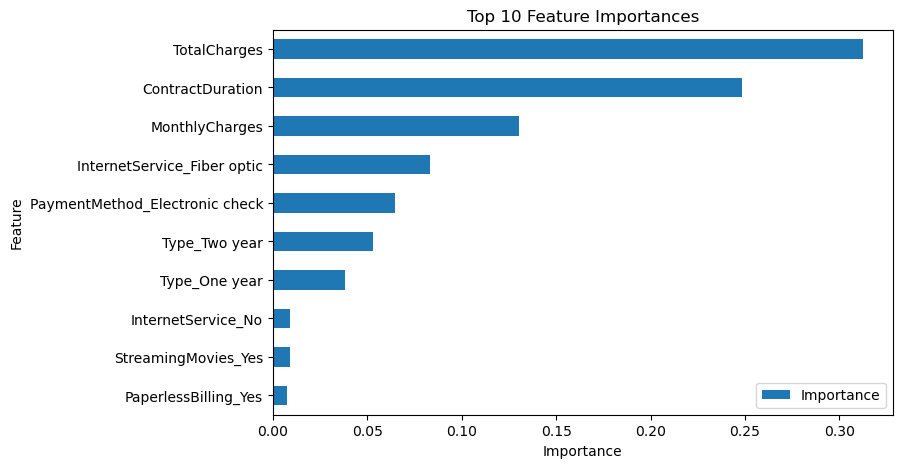

In [56]:
featureimportance = featureimportance.sort_values(
    by='Importance',
    ascending=True
)

featureimportance.tail(10).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(8,5)
)

plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

### Feature Importance Results

The feature importance analysis showed that **TotalCharges**, **ContractDuration**, and **MonthlyCharges** were the most influential predictors of customer churn.

These findings suggest that a customer's financial history and length of relationship with the company play an important role in predicting the likelihood of churn.

Additionally, **contract type** and **payment method** were among the most influential features, indicating that customer subscription characteristics and billing preferences are also valuable predictors of churn.

In [58]:
train_pred = best_gb.predict(x_train)
print('F1 Treino:', f1_score(y_train, train_pred))
print('F1 Teste:', f1_score(y_test, best_pred))

F1 Treino: 0.9217855780236551
F1 Teste: 0.7825059101654847


In [ ]:
#Resultados dos Modelos#

results = pd.DataFrame({
    'Model': [
        'Dummy Classifier',
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting',
        'Gradient Boosting (Tuned)'
    ],
    'Accuracy': [
        0.734,
        0.808,
        0.850,
        0.865,
        0.896
    ],
    'Precision': [
        0.000,
        0.666,
        0.788,
        0.857,
        0.876
    ],
    'Recall': [
        0.000,
        0.555,
        0.595,
        0.591,
        0.709
    ],
    'F1-score': [
        0.000,
        0.605,
        0.678,
        0.700,
        0.783
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Dummy Classifier,0.734,0.000,0.000,0.000
1,Logistic Regression,0.808,0.666,0.555,0.605
2,Random Forest,0.850,0.788,0.595,0.678
3,Gradient Boosting,0.865,0.857,0.591,0.700
4,Gradient Boosting (Tuned),0.896,0.876,0.709,0.783


# Conclusion

In this project, a machine learning model was developed to predict which **Interconnect** customers are most likely to cancel their services. Before model development, the data was cleaned, integrated, and prepared to ensure reliable and consistent model training.

Five different models were evaluated. After hyperparameter tuning, the **Gradient Boosting** model achieved the best overall performance, obtaining the highest **ROC-AUC** while also delivering strong results in **accuracy**, **precision**, **recall**, and an **F1-score of approximately 0.78**.

The feature importance analysis identified **TotalCharges**, **ContractDuration**, and **MonthlyCharges** as the most influential predictors of customer churn. These findings suggest that a customer's financial history and length of relationship with the company are key indicators of churn risk. Contract type and payment method also contributed to the model's predictive performance.

One limitation of this project is that the model was developed using only the available customer data. Additional information, such as customer support interactions, service quality metrics, or customer satisfaction data, could further improve predictive performance.

Overall, the optimized Gradient Boosting model provides an effective solution for identifying customers at higher risk of churn. By targeting these customers with personalized retention strategies, Interconnect can reduce customer attrition, optimize marketing efforts, and support more informed, data-driven business decisions.